# Risk Management Project 2 – Bonds Valuation and Hedging

## Introduction

In this project, we focus on the valuation and risk analysis of bonds using the term structure of interest rates. The objective is to construct the yield curve, compute bond prices, and analyze sensitivities such as duration and convexity.

## 1. Bonds and Interest Rates

A bond is a financial instrument through which an investor lends money to a borrower, usually a government or a corporation. In return, the issuer agrees to pay periodic interest (called coupons) and to repay the principal at maturity. Bonds are typically issued on primary markets, either through auctions or with the help of financial intermediaries.

There is an inverse relationship between bond prices and interest rates. When interest rates increase, new bonds offer higher returns, making existing bonds less attractive, so their price decreases. On the other hand, when interest rates decrease, existing bonds become more valuable, and their price increases.



## 2. Data Collection and Spot Yield Curve

In this section, we extract spot rates from the European Central Bank (ECB) yield curve for a specific date. The selected data corresponds to AAA-rated government bonds in the euro area.

We directly obtain 10 consecutive semi-annual spot rates over a 5-year horizon (from 0.5 to 5 years). These rates represent zero-coupon yields and will be used to construct the term structure of interest rates for bond valuation and risk analysis.

In [206]:
import pandas as pd

date_selected = "2026-03-19"

series = {
    "0.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M",
    "1.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y",
    "1.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M",
    "2.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y",
    "2.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M",
    "3.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y",
    "3.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M",
    "4.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y",
    "4.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M",
    "5.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y",
}

rows = []

for maturity, code in series.items():
    url = f"https://data-api.ecb.europa.eu/service/data/YC/{code.split('YC.')[1]}?format=csvdata"
    
    df_tmp = pd.read_csv(url)
    df_tmp.columns = [c.upper() for c in df_tmp.columns]

    value_row = df_tmp[df_tmp["TIME_PERIOD"] == date_selected]

    rows.append({
        "maturity": float(maturity.replace("Y", "")),
        "spot_rate": float(value_row["OBS_VALUE"].iloc[0])
    })

spot_df = pd.DataFrame(rows).sort_values("maturity")

# 🔥 sauvegarde directe dans data
spot_df.to_csv("../data/ecb_spot_rates.csv", index=False)

df = pd.read_csv("../data/ecb_spot_rates.csv")
df


,maturity,spot_rate
0,0.5,2.158183
1,1.0,2.337735
2,1.5,2.424372
3,2.0,2.468185
4,2.5,2.494950
5,3.0,2.517302
6,3.5,2.540909
7,4.0,2.567863
8,4.5,2.598506
9,5.0,2.632398


## 3. Spot Rate: Definition and Interpretation

A spot rate is the yield associated with a zero-coupon bond for a given maturity. It represents the rate used to discount a single future cash flow to its present value.

Each maturity has its own spot rate, which makes the spot curve a key tool for valuing bonds. Unlike yield to maturity, spot rates allow each cash flow to be discounted using a specific rate that matches its timing.

Spot rates are not directly observed for all maturities and are typically derived from market data using a bootstrapping process.

The shape of the spot yield curve provides insights into market expectations. An upward sloping curve generally indicates higher yields for longer maturities, reflecting risk premia and expectations about future economic conditions.

In [207]:
import pandas as pd

df = pd.read_csv("../data/ecb_spot_rates.csv")
df

,maturity,spot_rate
0,0.5,2.158183
1,1.0,2.337735
2,1.5,2.424372
3,2.0,2.468185
4,2.5,2.494950
5,3.0,2.517302
6,3.5,2.540909
7,4.0,2.567863
8,4.5,2.598506
9,5.0,2.632398


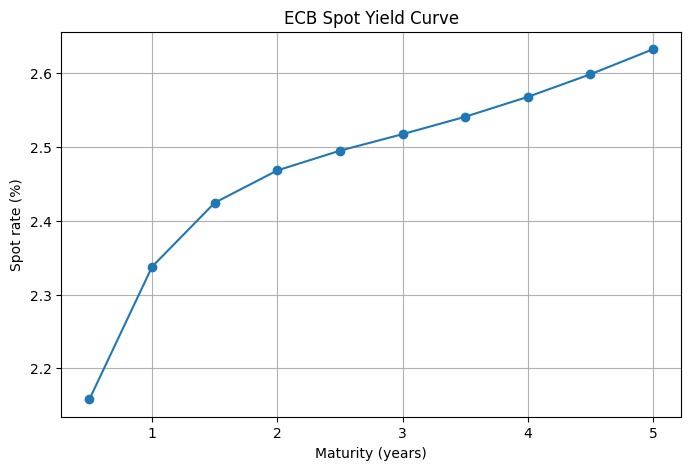

In [208]:
import matplotlib.pyplot as plt
maturities = df["maturity"].tolist()
spot_rates_pct = df["spot_rate"].tolist()

plt.figure(figsize=(8,5))
plt.plot(maturities, spot_rates_pct, marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Spot rate (%)")
plt.title("ECB Spot Yield Curve")
plt.grid(True)
plt.show()

## 4. Interpolation of a Missing Spot Rate

In this section, we estimate the 1.5-year spot rate using linear interpolation between the 1-year and 2-year spot rates. We then compare the interpolated value with the actual ECB value.

In [209]:
# Q4 - Interpolate the 1.5Y spot rate and compare it with the ECB value

# Read the spot rates saved in the local data folder
import pandas as pd

df = pd.read_csv("../data/ecb_spot_rates.csv")

# Extract the two surrounding spot rates: 1Y and 2Y
r_1y = df.loc[df["maturity"] == 1.0, "spot_rate"].values[0]
r_2y = df.loc[df["maturity"] == 2.0, "spot_rate"].values[0]

# Linear interpolation for the 1.5Y maturity
t1 = 1.0
t2 = 2.0
t_mid = 1.5

r_interp = r_1y + (r_2y - r_1y) * (t_mid - t1) / (t2 - t1)

# Actual ECB value for 1.5Y
r_actual = df.loc[df["maturity"] == 1.5, "spot_rate"].values[0]

# Pricing interpolation error
interp_error = r_interp - r_actual
abs_error = abs(interp_error)

print("Q4 Results")
print("----------")
print("1Y spot rate (%):", r_1y)
print("2Y spot rate (%):", r_2y)
print("Interpolated 1.5Y spot rate (%):", r_interp)
print("Actual ECB 1.5Y spot rate (%):", r_actual)
print("Interpolation error:", interp_error)
print("Absolute error:", abs_error)

Q4 Results
----------
1Y spot rate (%): 2.3377346321
2Y spot rate (%): 2.4681846638
Interpolated 1.5Y spot rate (%): 2.40295964795
Actual ECB 1.5Y spot rate (%): 2.4243723534
Interpolation error: -0.021412705449999958
Absolute error: 0.021412705449999958


In [210]:
# Q4 - Summary table for interpolation comparison

comparison_q4 = pd.DataFrame({
    "Maturity": [1.0, 1.5, 2.0],
    "Spot Rate (%)": [r_1y, r_actual, r_2y]
})

comparison_q4

,Maturity,Spot Rate (%)
0,1.0,2.337735
1,1.5,2.424372
2,2.0,2.468185


### Interpretation

The interpolated 1.5-year spot rate is very close to the actual ECB value, with a small error of about 0.02%. This confirms that linear interpolation provides a reasonable approximation when the yield curve is smooth.

The interpolated value slightly underestimates the actual rate, suggesting that the yield curve is mildly convex rather than perfectly linear between maturities.

## 5. Pricing of STRIPS

A STRIP is a zero-coupon bond. It pays a single cash flow at maturity, so its price is obtained by discounting this payment using the corresponding spot rate.

$$
P = \frac{M}{\left(1+\frac{s_i}{m}\right)^i}
$$

Where:
- \(M\) is the par value
- \(s_i\) is the spot rate
- \(m\) is the number of periods per year
- \(i\) is the number of periods

In [211]:
# Q5 - Calculate the prices of the 10 STRIPS from the 10 ECB spot rates

import pandas as pd

# Read the ECB spot rates saved in the local data folder
df = pd.read_csv("../data/ecb_spot_rates.csv")

# Parameters
PAR_VALUE = 100
M = PAR_VALUE
m = 2   # semi-annual compounding

# Manual computation of STRIPS prices
strip_rows = []

for _, row in df.iterrows():
    maturity_years = row["maturity"]
    spot_rate_pct = row["spot_rate"]
    s_i = spot_rate_pct / 100.0
    i = int(maturity_years * m)   # number of semi-annual periods

    # STRIP pricing equation:
    # P = M / (1 + s_i / m)^i
    strip_price = M / ((1 + s_i / m) ** i)

    if strip_price < M:
        status = "Below par"
    elif strip_price > M:
        status = "Above par"
    else:
        status = "At par"

    strip_rows.append({
        "Maturity (years)": maturity_years,
        "Periods i": i,
        "Spot rate (%)": spot_rate_pct,
        "STRIP price (€)": strip_price,
        "Position vs par": status
    })

df_strips = pd.DataFrame(strip_rows)

print("Q5 Results")
print("----------")
print(df_strips)

df_strips

# Q5 - Save STRIPS prices

df_strips.to_csv("../data/strip_prices.csv", index=False)

Q5 Results
----------
   Maturity (years)  Periods i  Spot rate (%)  STRIP price (€) Position vs par
0               0.5          1       2.158183        98.932429       Below par
1               1.0          2       2.337735        97.702623       Below par
2               1.5          3       2.424372        96.449856       Below par
3               2.0          4       2.468185        95.212250       Below par
4               2.5          5       2.494950        93.989425       Below par
5               3.0          6       2.517302        92.769919       Below par
6               3.5          7       2.540909        91.542061       Below par
7               4.0          8       2.567863        90.297472       Below par
8               4.5          9       2.598506        89.031525       Below par
9               5.0         10       2.632398        87.742725       Below par


### Interpretation

All STRIPS are priced below par, which is expected since they are zero-coupon bonds discounted using positive spot rates.

Moreover, prices decrease as maturity increases, reflecting the stronger impact of discounting over longer horizons. This is consistent with the upward-sloping spot yield curve observed earlier.

## 6. Forward Rates

Forward rates represent future interest rates implied by the current spot curve.

They are derived from spot rates using:

$$
(1 + s_n)^n = (1 + s_m)^m \times (1 + f_{m,n})^{n-m}
$$

Where:
- \(s_n, s_m\) are spot rates
- \(f_{m,n}\) is the forward rate between maturities

In [212]:
# Q6 - Compute forward rates from spot rates

import pandas as pd

# Read spot rates
df = pd.read_csv("../data/ecb_spot_rates.csv")

m = 2  # semi-annual

forward_rows = []

for i in range(1, len(df)):
    
    # previous maturity
    t1 = df.loc[i-1, "maturity"]
    s1 = df.loc[i-1, "spot_rate"] / 100
    
    # current maturity
    t2 = df.loc[i, "maturity"]
    s2 = df.loc[i, "spot_rate"] / 100
    
    n1 = int(t1 * m)
    n2 = int(t2 * m)
    
    # Forward rate formula:
    # (1 + s2/m)^n2 = (1 + s1/m)^n1 * (1 + f/m)^(n2 - n1)
    
    f = ((1 + s2/m)**n2 / (1 + s1/m)**n1)**(1/(n2 - n1)) - 1
    
    forward_rows.append({
        "From": t1,
        "To": t2,
        "Forward rate (%)": f * 100
    })

df_forward = pd.DataFrame(forward_rows)

print("Q6 Results")
print("----------")
print(df_forward)

df_forward

df_forward.to_csv("../data/forward_rates.csv", index=False)

Q6 Results
----------
   From   To  Forward rate (%)
0   0.5  1.0          1.258723
1   1.0  1.5          1.298880
2   1.5  2.0          1.299839
3   2.0  2.5          1.301024
4   2.5  3.0          1.314549
5   3.0  3.5          1.341305
6   3.5  4.0          1.378321
7   4.0  4.5          1.421908
8   4.5  5.0          1.468840


### Interpretation

Forward rates are generally increasing with maturity, which suggests that the market expects higher interest rates in the future.

This is consistent with the upward-sloping spot yield curve observed earlier.

## 7. Bond Pricing

The price of a coupon bond is equal to the present value of all future cash flows, discounted using the corresponding spot rates.

$$
P = \sum_{i=1}^{N} \frac{C}{\left(1+\frac{s_i}{m}\right)^i} + \frac{M}{\left(1+\frac{s_N}{m}\right)^N}
$$

Where:
- \(C\) is the coupon payment
- \(M\) is the par value
- \(s_i\) are the spot rates
- \(m\) is the number of payments per year
- \(N\) is the number of periods

In [213]:
# Q7 - Price the 3-year French government bond using spot rates

import pandas as pd

# Read spot rates
df = pd.read_csv("../data/ecb_spot_rates.csv")

# Bond parameters from the project statement
M = 1000
coupon_rate = 0.02
m = 2
T = 3

N = int(T * m)
C = M * coupon_rate / m

price = 0

for i in range(1, N + 1):
    t = i / m
    s = df.loc[df["maturity"] == t, "spot_rate"].values[0] / 100

    # Discount coupon cash flow
    price += C / ((1 + s / m) ** i)

# Discount principal repayment
sN = df.loc[df["maturity"] == T, "spot_rate"].values[0] / 100
price += M / ((1 + sN / m) ** N)

print("Q7 Results")
print("----------")
print("Par value:", M)
print("Coupon rate (%):", coupon_rate * 100)
print("Coupon per period:", C)
print("Bond price:", price)

Q7 Results
----------
Par value: 1000
Coupon rate (%): 2.0
Coupon per period: 10.0
Bond price: 985.2048407464862



### Interpretation

The bond is priced below par (≈ 985), which indicates that the coupon rate (2%) is lower than the market spot rates.

As a result, the bond offers lower returns than current market conditions, so it is traded at a discount.

## 8. Dirty Price and Clean Price

We assume that the bond is purchased 50 days after issuance. Since the transaction does not occur on a coupon date, accrued interest must be taken into account.

The dirty price is given by:

$$
P = \sum_{i=0}^{N-1} \frac{C}{\left(1+\frac{s_i}{m}\right)^{i+w}} + \frac{M}{\left(1+\frac{s_N}{m}\right)^{N-1+w}}
$$

where

$$
w = \frac{\text{days until next coupon}}{\text{days in coupon period}}
$$

Accrued interest is:

$$
AI = C \times \frac{\text{days since last coupon}}{\text{days in coupon period}}
$$

and

$$
\text{Clean price} = \text{Dirty price} - AI
$$

In [214]:
# Q8 - Compute the dirty price and the clean price 50 days after issuance

import pandas as pd

df = pd.read_csv("../data/ecb_spot_rates.csv")

# Bond parameters from the project statement
M = 1000
coupon_rate = 0.02
m = 2
T = 3

N = int(T * m)
C = M * coupon_rate / m

# 50 days after issuance
days_since_last_coupon = 50
days_in_coupon_period = 180
days_until_next_coupon = days_in_coupon_period - days_since_last_coupon

w = days_until_next_coupon / days_in_coupon_period

# Dirty price using spot rates
dirty_price = 0

for i in range(N):
    t = (i + 1) / m
    s = df.loc[df["maturity"] == t, "spot_rate"].values[0] / 100
    dirty_price += C / ((1 + s / m) ** (i + w))

sN = df.loc[df["maturity"] == T, "spot_rate"].values[0] / 100
dirty_price += M / ((1 + sN / m) ** (N - 1 + w))

# Accrued interest
accrued_interest = C * (days_since_last_coupon / days_in_coupon_period)

# Clean price
clean_price = dirty_price - accrued_interest

print("Dirty price:", round(dirty_price, 2))
print("Accrued interest:", round(accrued_interest, 2))
print("Clean price:", round(clean_price, 2))

Dirty price: 988.62
Accrued interest: 2.78
Clean price: 985.85


### Interpretation

The dirty price is higher than the clean price because it includes accrued interest.

Since the bond is purchased 50 days after issuance, part of the coupon has already been earned by the seller. The buyer must therefore compensate for this accrued interest, which explains the difference between the two prices.

## 9. Yield to Maturity (YTM)

The yield to maturity is the single discount rate that makes the present value of all bond cash flows equal to the bond price.

$$
P = \sum_{i=1}^{N} \frac{C}{\left(1+\frac{y}{m}\right)^i} + \frac{M}{\left(1+\frac{y}{m}\right)^N}
$$

Where:
- \(P\) is the bond price
- \(C\) is the coupon payment
- \(M\) is the par value
- \(y\) is the yield to maturity
- \(m\) is the number of coupon payments per year
- \(N\) is the total number of periods

In [215]:
# Q9 - Estimate the YTM of the bond priced in Q7

# Bond parameters from Q7
P = price
M = 1000
coupon_rate = 0.02
m = 2
T = 3

N = int(T * m)
C = M * coupon_rate / m

# Manual search for the YTM
best_y = None
best_error = 10**9
best_price = None

y = 0.0001
step = 0.000001

while y <= 0.10:
    test_price = 0
    
    for i in range(1, N + 1):
        test_price += C / ((1 + y / m) ** i)
    
    test_price += M / ((1 + y / m) ** N)
    
    error = abs(test_price - P)
    
    if error < best_error:
        best_error = error
        best_y = y
        best_price = test_price
    
    y += step

print("YTM:", round(best_y * 100, 4), "%")
print("Price from YTM:", round(best_price, 4))
print("Observed price:", round(P, 4))

YTM: 2.5151 %
Price from YTM: 985.205
Observed price: 985.2048


### Interpretation

The estimated YTM is 2.5151%, which is above the coupon rate of 2%. This is consistent with the fact that the bond is priced below par.

The price obtained with the estimated YTM is almost identical to the observed bond price, which confirms that the approximation is accurate.

### 10.c Estimated Change in Bond Price for a 1.8% Yield Shock

Using duration and convexity, the relative change in bond price is approximated by:

$$
\frac{\Delta BV}{BV_0}
= -D \cdot \Delta y + \frac{1}{2} Cx \cdot (\Delta y)^2
$$

Therefore, the absolute change in price is:

$$
\Delta BV = BV_0 \times \left(-D \cdot \Delta y + \frac{1}{2} Cx \cdot (\Delta y)^2 \right)
$$

Where:
- $D$ is duration  
- $Cx$ is convexity  
- $BV_0$ is the bond value  
- $\Delta y$ is the yield change

In [216]:
# Q10 - Bond Sensitivity Measures (DV01, Duration, Convexity, Price change)

# Parameters (same as Q7 & Q9)
M = 1000
coupon_rate = 0.02
m = 2
T = 3

N = int(T * m)
C = M * coupon_rate / m

BV0 = price      # bond price from Q7
y0 = best_y      # YTM from Q9


# =========================
# Q10.a - DV01 (5 bps)
# =========================

delta_y = -0.0005  # -5 bps

y_down = y0 + delta_y

BV_down = 0
for i in range(1, N + 1):
    BV_down += C / ((1 + y_down / m) ** i)

BV_down += M / ((1 + y_down / m) ** N)

DV01 = - (BV_down - BV0) / (10000 * delta_y)


# =========================
# Q10.b - Duration & Convexity (±0.55%)
# =========================

delta_y = 0.0055

y_down = y0 - delta_y
y_up = y0 + delta_y

BV_down = 0
BV_up = 0

for i in range(1, N + 1):
    BV_down += C / ((1 + y_down / m) ** i)
    BV_up += C / ((1 + y_up / m) ** i)

BV_down += M / ((1 + y_down / m) ** N)
BV_up += M / ((1 + y_up / m) ** N)

duration = (BV_down - BV_up) / (2 * BV0 * delta_y)
convexity = (BV_down + BV_up - 2 * BV0) / (BV0 * (delta_y ** 2))


# =========================
# Q10.c - Price change (±1.8%)
# =========================

delta_y = 0.018

delta_BV_down = BV0 * (-duration * (-delta_y) + 0.5 * convexity * ((-delta_y) ** 2))
delta_BV_up = BV0 * (-duration * (delta_y) + 0.5 * convexity * ((delta_y) ** 2))

price_down = BV0 + delta_BV_down
price_up = BV0 + delta_BV_up


# =========================
# OUTPUT (clean)
# =========================

print("DV01:", round(DV01, 6))
print("Duration:", round(duration, 6))
print("Convexity:", round(convexity, 6))

print("Price (-1.8%):", round(price_down, 2))
print("Price (+1.8%):", round(price_up, 2))

DV01: 0.284967
Duration: 2.88991
Convexity: 9.914256
Price (-1.8%): 1038.04
Price (+1.8%): 935.54


### Interpretation

The DV01 is positive, which confirms that the bond price increases when yields decrease.

The duration of about 2.89 shows that the bond is moderately sensitive to interest rate changes. The convexity is also positive, which is expected for a standard bond and reflects the curvature of the price-yield relationship.

For a yield shock of -1.8%, the bond price increases to about 1038.04. For a yield shock of +1.8%, the bond price falls to about 935.54. This is consistent with the inverse relationship between bond prices and yields.

The gain when yields fall is slightly larger than the loss when yields rise by the same magnitude, which is explained by positive convexity.

## 11. Hedging Strategies

In this section, we analyze how to hedge the interest rate risk of the bond priced in Question 7.

We assume a position of €7.3 million in this bond and construct hedging strategies using other bonds.

We consider three approaches:
- DV01 hedge
- Duration hedge
- Duration and convexity hedge

In [217]:
# Q11 - Prepare the two hedging instruments

import pandas as pd

df = pd.read_csv("../data/ecb_spot_rates.csv")

m = 2
PAR = 1000

# -------------------------
# Hedge bond 1: 1-year zero-coupon bond
# -------------------------
T1 = 1.0
N1 = int(T1 * m)
s1 = df.loc[df["maturity"] == T1, "spot_rate"].values[0] / 100

P1 = PAR / ((1 + s1 / m) ** N1)

# DV01 of hedge bond 1
dy = -0.0001
P1_down = PAR / ((1 + (s1 + dy) / m) ** N1)
DV01_1 = - (P1_down - P1) / (10000 * dy)

# Duration and convexity of hedge bond 1
dy_dur = 0.0055
P1_minus = PAR / ((1 + (s1 - dy_dur) / m) ** N1)
P1_plus = PAR / ((1 + (s1 + dy_dur) / m) ** N1)

D1 = (P1_minus - P1_plus) / (2 * P1 * dy_dur)
Cx1 = (P1_minus + P1_plus - 2 * P1) / (P1 * dy_dur**2)

# -------------------------
# Hedge bond 2: 5-year zero-coupon bond
# -------------------------
T2 = 5.0
N2 = int(T2 * m)
s2 = df.loc[df["maturity"] == T2, "spot_rate"].values[0] / 100

P2 = PAR / ((1 + s2 / m) ** N2)

# DV01 of hedge bond 2
P2_down = PAR / ((1 + (s2 + dy) / m) ** N2)
DV01_2 = - (P2_down - P2) / (10000 * dy)

# Duration and convexity of hedge bond 2
P2_minus = PAR / ((1 + (s2 - dy_dur) / m) ** N2)
P2_plus = PAR / ((1 + (s2 + dy_dur) / m) ** N2)

D2 = (P2_minus - P2_plus) / (2 * P2 * dy_dur)
Cx2 = (P2_minus + P2_plus - 2 * P2) / (P2 * dy_dur**2)

print("Bond 1 price:", round(P1, 4))
print("Bond 1 DV01:", round(DV01_1, 6))
print("Bond 1 Duration:", round(D1, 6))
print("Bond 1 Convexity:", round(Cx1, 6))

print("Bond 2 price:", round(P2, 4))
print("Bond 2 DV01:", round(DV01_2, 6))
print("Bond 2 Duration:", round(D2, 6))
print("Bond 2 Convexity:", round(Cx2, 6))

Bond 1 price: 977.0262
Bond 1 DV01: 0.096581
Bond 1 Duration: 0.988461
Bond 1 Convexity: 1.465557
Bond 2 price: 877.4273
Bond 2 DV01: 0.433132
Bond 2 Duration: 4.935845
Bond 2 Convexity: 26.792702


### 11.a DV01 Hedge

The hedge ratio is:

$$
HR = \frac{DV01_{OP}}{DV01_{HI}}
$$

The hedge position is then obtained by multiplying this ratio by the size of the open position.

In [218]:
# Q11.a - DV01 hedge using the 1-year zero-coupon bond

V_OP = 7_300_000
DV01_OP = DV01
DV01_HI = DV01_1

HR_DV01 = DV01_OP / DV01_HI
hedge_face_value_DV01 = V_OP * HR_DV01

print("DV01 hedge ratio:", round(HR_DV01, 6))
print("DV01 hedge face value ($):", round(hedge_face_value_DV01, 2))

DV01 hedge ratio: 2.950546
DV01 hedge face value ($): 21538982.64


### Interpretation

The DV01 hedge uses the 1-year zero-coupon bond to offset the first-order sensitivity of the initial bond position to very small changes in yield.

Since the initial position is long, the hedge position should be taken in the opposite direction.

### 11.b Duration Hedge

Using the duration formula from the slides:

$$
V_{HI} = - \frac{D_{OP} \times V_{OP}}{D_{HI}}
$$

In [219]:
# Q11.b - Duration hedge using the 5-year zero-coupon bond

D_OP = duration
D_HI = D2
V_OP = 7_300_000

V_HI_duration = - (D_OP * V_OP) / D_HI

print("Duration hedge value ($):", round(V_HI_duration, 2))

Duration hedge value ($): -4274109.46


### Interpretation

The duration hedge removes the first-order percentage sensitivity of the position to parallel shifts in yields.

A negative hedge value means that the hedging bond must be shorted.

### 11.c Duration and Convexity Hedge

To hedge both duration and convexity, the following system must be satisfied:

$$
V_{OP} D_{OP} - V_{HI1} D_{HI1} - V_{HI2} D_{HI2} = 0
$$

$$
V_{OP} Cx_{OP} - V_{HI1} Cx_{HI1} - V_{HI2} Cx_{HI2} = 0
$$

In [220]:
# Q11.c - Duration and convexity hedge using the two zero-coupon bonds

V_OP = 7_300_000
D_OP = duration
Cx_OP = convexity

# Solve the 2x2 system manually
# V_OP*D_OP - V1*D1 - V2*D2 = 0
# V_OP*Cx_OP - V1*Cx1 - V2*Cx2 = 0

A11 = D1
A12 = D2
B1 = V_OP * D_OP

A21 = Cx1
A22 = Cx2
B2 = V_OP * Cx_OP

det = A11 * A22 - A12 * A21

V1 = (B1 * A22 - B2 * A12) / det
V2 = (A11 * B2 - A21 * B1) / det

print("Hedge bond 1 value ($):", round(V1, 2))
print("Hedge bond 2 value ($):", round(V2, 2))

Hedge bond 1 value ($): 10805362.55
Hedge bond 2 value ($): 2110208.56


### Interpretation

This hedge uses two instruments to neutralize both duration and convexity.

It is more accurate than a simple duration hedge, especially when interest rate changes are larger.